<a href="https://colab.research.google.com/github/Rosse2025/sw-kg/blob/main/coco_25000_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import tarfile
import random
from PIL import Image, ImageFile


# Configuración do dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


In [11]:
from io import BytesIO
from google.colab import drive
# Monta la unidad de Google Drive para habilitar el acceso
drive.mount('/content/drive')

RUTA_DRIVE = "/content/drive/MyDrive/buscador_imagenes/"
RUTA_DESTINO_COLAB = "/content/"

print("Copiando archivos desde Drive a Colab...")

# Usa el comando de sistema cp -r para una transferencia masiva y veloz
if os.path.exists(RUTA_DRIVE):
    !cp -r "{RUTA_DRIVE}"* "{RUTA_DESTINO_COLAB}"
    print("Transferencia completada correctamente")
else:
    print("Error: La ruta de Drive no es accesible o no existe")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copiando archivos desde Drive a Colab...
Transferencia completada correctamente


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Codigo de la practica adaptado a COCO

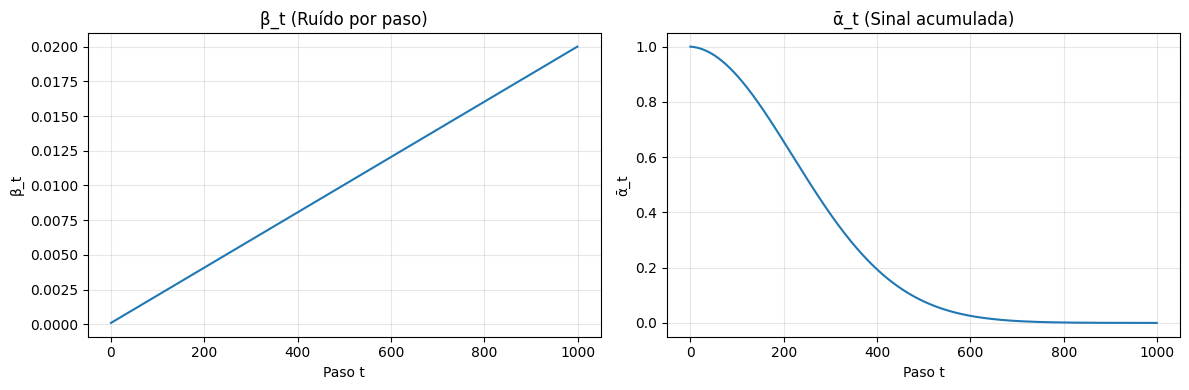

In [13]:
def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    """
    Crea un variance schedule lineal.

    Args:
        timesteps: número de pasos de difusión (T)
        beta_start: β_1
        beta_end: β_T

    Returns:
        beta_t: variance en cada paso
        alpha_t: 1 - β_t
        alpha_bar_t: produto acumulado de alpha_t
    """
    beta_t = torch.linspace(beta_start, beta_end, timesteps)
    alpha_t = 1.0 - beta_t
    alpha_bar_t = torch.cumprod(alpha_t, dim=0)

    return beta_t, alpha_t, alpha_bar_t

# Hiperparámetros
T = 1000  # Número de pasos de difusión
beta_t, alpha_t, alpha_bar_t = linear_beta_schedule(T)

# Visualización do schedule
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(beta_t.numpy())
ax1.set_title('β_t (Ruído por paso)')
ax1.set_xlabel('Paso t')
ax1.set_ylabel('β_t')
ax1.grid(True, alpha=0.3)

ax2.plot(alpha_bar_t.numpy())
ax2.set_title('ᾱ_t (Sinal acumulada)')
ax2.set_xlabel('Paso t')
ax2.set_ylabel('ᾱ_t')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
class TimeEmbedding(nn.Module):
    """Embedding sinusoidal para o tempo t."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat([torch.sin(embeddings), torch.cos(embeddings)], dim=-1)
        return embeddings


class ResBlock(nn.Module):
    """Bloque residual con inxección de tempo."""
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        def get_num_groups(channels):
                for g in [8, 4, 2, 1]:
                    if channels % g == 0:
                        return g

        # Primeira metade do bloque
        self.gn1 = nn.GroupNorm(get_num_groups(in_channels), in_channels) # Normaliza a entrada
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        # Proxección do time embedding ao número de canles
        self.time_embedding_projector = nn.Linear(time_emb_dim, out_channels)

        # Segunda metade do bloque
        self.gn2 = nn.GroupNorm(get_num_groups(out_channels), out_channels)  # Normaliza despois da primeira conv
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        # Conexión residual
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, t_emb):
        # Primeira parte: GN → SiLU → Conv
        h = self.gn1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # Inxección do embedding temporal
        projected_t_emb = self.time_embedding_projector(t_emb)
        h = h + projected_t_emb[:, :, None, None]

        # Segunda parte: GN → SiLU → Conv
        h = self.gn2(h)
        h = F.silu(h)
        h = self.conv2(h)

        # Conexión residual
        return h + self.residual_conv(x)


class SimpleUNet(nn.Module):
    """U-Net simplificada para MNIST (28x28)."""
    def __init__(self, in_channels=3, out_channels=3, time_emb_dim=128, base_channels=64):
        super().__init__()

        # Time embedding
        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        # Encoder (downsampling)
        self.conv_in = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        self.down1 = ResBlock(base_channels, base_channels, time_emb_dim)
        self.down2 = ResBlock(base_channels, base_channels * 2, time_emb_dim)
        self.down3 = ResBlock(base_channels * 2, base_channels * 4, time_emb_dim)

        # Bottleneck
        self.bottleneck = ResBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        # Decoder (upsampling)
        self.up1 = ResBlock(base_channels * 8, base_channels * 2, time_emb_dim)
        self.up2 = ResBlock(base_channels * 4, base_channels, time_emb_dim)
        self.up3 = ResBlock(base_channels*2, base_channels, time_emb_dim)

        # Output
        self.conv_out = nn.Conv2d(base_channels, out_channels, 1)

        # Pooling e upsampling
        self.pool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t):
        # Time embedding
        t_emb = self.time_mlp(t)

        # Encoder
        x1 = self.conv_in(x)
        x1 = self.down1(x1, t_emb)  # 64x64

        x2 = self.pool(x1)
        x2 = self.down2(x2, t_emb)  # 32x32

        x3 = self.pool(x2)
        x3 = self.down3(x3, t_emb)  # 16x16

        x4 = self.pool(x3)

        # Bottleneck

        x4 = self.bottleneck(x4, t_emb) # 8x8

        # Decoder con skip connections
        # 8x8 -> 16x16
        x = self.upsample(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.up1(x, t_emb)

        # 16x16 -> 32x32
        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, t_emb)

        # 32x32 -> 64x64
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up3(x, t_emb)


        # Output
        return self.conv_out(x)

In [15]:
def forward_diffusion(x0, t, alpha_bar_t):
    """
    Proceso de forward diffusion: engade ruído a x0.

    x_t = √(ᾱ_t) * x0 + √(1 - ᾱ_t) * ε

    Args:
        x0: imaxe orixinal [batch, channels, height, width]
        t: pasos de tempo [batch]
        alpha_bar_t: valores de ᾱ_t

    Returns:
        x_t: imaxe con ruído
        epsilon: ruído engadido
    """

    # Extraer ᾱ_t para cada t no batch
    alpha_bar = alpha_bar_t[t].view(-1, 1, 1, 1)

    # Xerar ruído gaussiano
    epsilon = torch.normal(mean=torch.zeros_like(x0), std=torch.ones_like(x0))

    # Aplicar forward diffusion
    x_t = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * epsilon

    return x_t, epsilon


def sample_timesteps(batch_size, timesteps):
    """Mostrear pasos de tempo aleatorios."""
    return torch.randint(0, timesteps, (batch_size,))

#**Elegimos numero de imagenes para entrenamiento**


In [43]:
n_img_train=20000


In [17]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

tar_path = "imagenes_animales.tar"
output_dir = "animals_64x64/data"

os.makedirs(output_dir, exist_ok=True)

with tarfile.open(tar_path, "r") as tar:

    members = [m for m in tar.getmembers() if m.name.endswith(".jpg")]
    selected = random.sample(members, min(20000, len(members)))

    count = 0

    for member in selected:
        try:
            f = tar.extractfile(member)
            if f is None:
                continue

            img = Image.open(BytesIO(f.read())).convert("RGB")
            img = img.resize((64, 64))

            fname = os.path.basename(member.name)
            img.save(os.path.join(output_dir, fname))

            count += 1

        except Exception as e:
            # simplemente saltar imágenes corruptas
            continue

print(f"Imágenes guardadas: {count}")

Imágenes guardadas: 20000


#**Definimos mismas épocas para todos los experimentos**

In [44]:
n_epocas=10

Dataset cargado: 22150 imaxes de adestramento


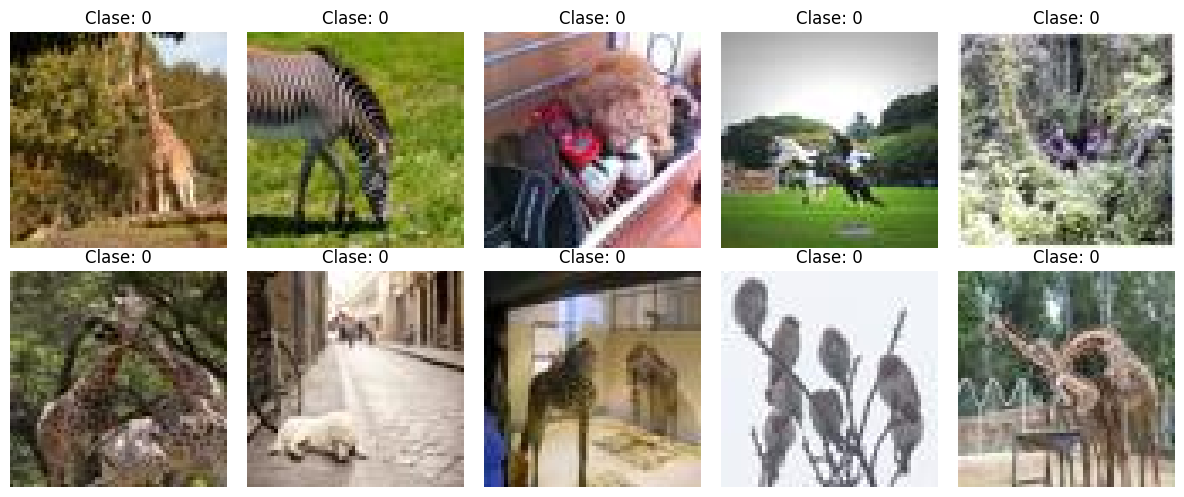

In [19]:
# Transformacións
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  #  RGB  # Normalizar a [-1, 1]
])

# Cargar COCO
train_dataset = datasets.ImageFolder(root="animals_64x64",  transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)

print(f'Dataset cargado: {len(train_dataset)} imaxes de adestramento')

# Visualizar algunhas imaxes
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    # Desnormalizar
    img = img * 0.5 + 0.5

    # Cambiar formato para matplotlib
    img = img.permute(1, 2, 0)

    ax.imshow(img)
    ax.set_title(f'Clase: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Iniciando adestramento por 30 épocas...



Época 10/30: 100%|██████████| 174/174 [00:09<00:00, 17.50it/s, loss=0.0116]


Época 10/30 - Perda media: 0.0355


Época 20/30: 100%|██████████| 174/174 [00:09<00:00, 17.41it/s, loss=0.0388]


Época 20/30 - Perda media: 0.0318


Época 30/30: 100%|██████████| 174/174 [00:09<00:00, 17.45it/s, loss=0.0325]


Época 30/30 - Perda media: 0.0303

Adestramento completado!


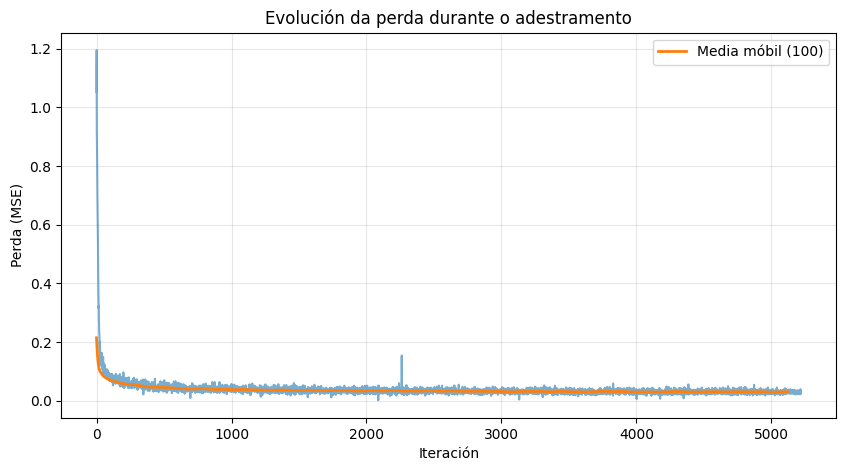

In [20]:
# Inicializar modelo
model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# Mover schedules ao dispositivo
beta_t = beta_t.to(device)
alpha_t = alpha_t.to(device)
alpha_bar_t = alpha_bar_t.to(device)

# Hiperparámetros de adestramento
num_epochs = n_epocas

print(f'Iniciando adestramento por {num_epochs} épocas...\n')

# Historial de perdas
losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    #mostrar_barra = (epoch + 1) % 10 == 0
    #pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{num_epochs}', disable=not mostrar_barra)

    pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{num_epochs}')
    for batch_idx, (x0, _) in enumerate(pbar):
        x0 = x0.to(device)
        batch_size = x0.shape[0]

        # Mostrear pasos de tempo aleatorios
        #t = sample_timesteps(batch_size, T).to(device)
        # t normalizado para o modelo
        t = sample_timesteps(batch_size, T).to(device).float() / T

        # t entero para indexing
        t_int = (t * (T - 1)).long()

        # Forward diffusion (engadir ruído)
        #x_t, epsilon = forward_diffusion(x0, t, alpha_bar_t)
        x_t, epsilon = forward_diffusion(x0, t_int, alpha_bar_t)

        # Predecir o ruído
        epsilon_pred = model(x_t, t)

        # Calcular perda (MSE entre ruído real e predicido)
        loss = F.mse_loss(epsilon_pred, epsilon)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        losses.append(loss.item())

        # Actualizar barra de progreso
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:

      print(f'Época {(epoch+1)}/{num_epochs} - Perda media: {avg_loss:.4f}')



print('\nAdestramento completado!')

# Visualizar curva de perda
plt.figure(figsize=(10, 5))
plt.plot(losses, alpha=0.6)
plt.plot(np.convolve(losses, np.ones(100)/100, mode='valid'), linewidth=2, label='Media móbil (100)')
plt.xlabel('Iteración')
plt.ylabel('Perda (MSE)')
plt.title('Evolución da perda durante o adestramento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Xerando imaxes novas...


Xerando imaxes: 100%|██████████| 1000/1000 [00:04<00:00, 201.31it/s]


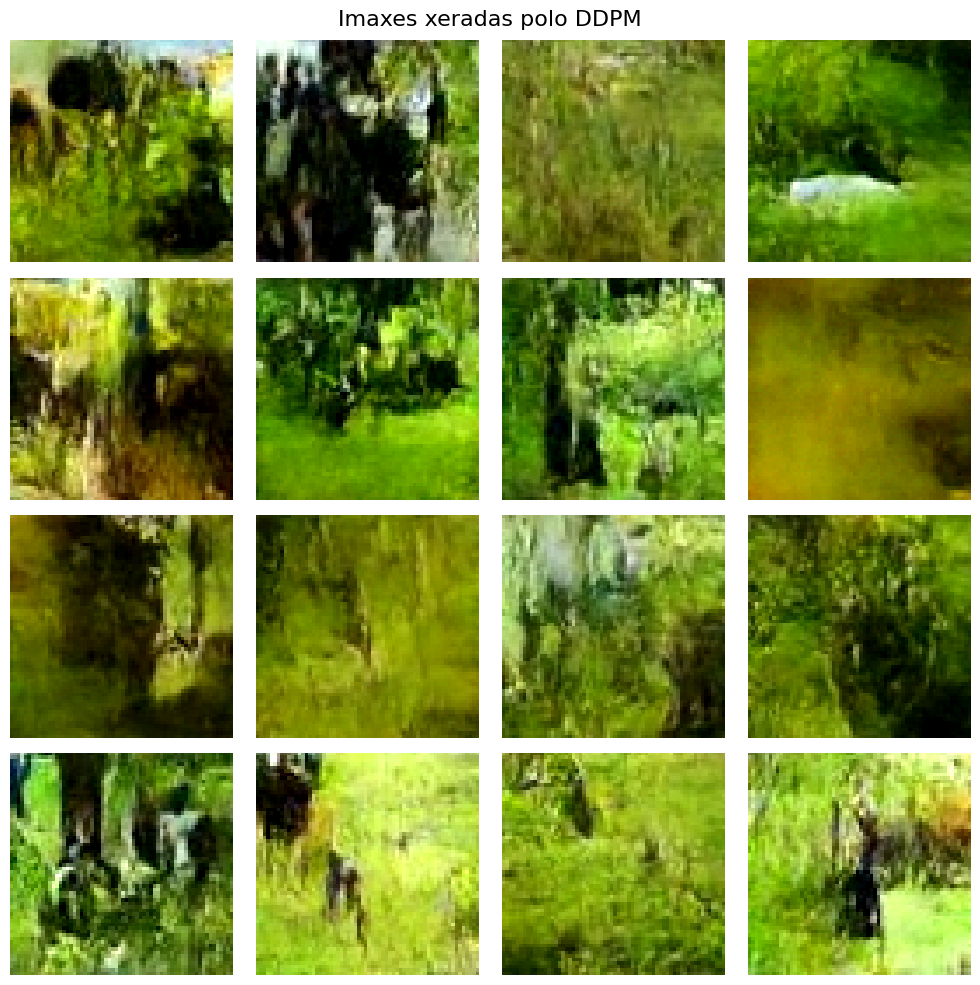

In [21]:
@torch.no_grad()
def sample_images(model, n_samples=16, image_size=64,channels=3):
    """
    Xera imaxes utilizando reverse diffusion.

    Args:
        model: modelo adestrado
        n_samples: número de imaxes a xerar
        image_size: tamaño das imaxes

    Returns:
        imaxes xeradas
    """
    model.eval()
    device = next(model.parameters()).device
    '''
    # Comezar con ruído puro
    x_t = torch.normal(
        mean=torch.zeros(n_samples, 1, image_size, image_size, device=device),
        std=torch.ones(n_samples, 1, image_size, image_size, device=device)
    )'''

    # 1. Comenzar con ruido puro (canales para RGB)
    x_t = torch.randn((n_samples, channels, image_size, image_size), device=device)

    # Reverse diffusion
    for t in tqdm(reversed(range(T)), desc='Xerando imaxes', total=T):
        #t_batch = torch.full((n_samples,), t, dtype=torch.long).to(device)
        # t normalizado para el TimeEmbedding del modelo
        t_batch = torch.full((n_samples,), t, device=device).float() / T

        # Predecir o ruído
        epsilon_pred = model(x_t, t_batch)

        # Calcular coeficientes y redimensionar para broadcasting [batch, 1, 1, 1]
        alpha = alpha_t[t].view(-1, 1, 1, 1).to(device)
        alpha_bar = alpha_bar_t[t].view(-1, 1, 1, 1).to(device)
        beta = beta_t[t].view(-1, 1, 1, 1).to(device)

        # Calcular x_{t-1}
        if t > 0:
            z = torch.normal(mean=torch.zeros_like(x_t), std=torch.ones_like(x_t))
            sigma_t = torch.sqrt(beta)
        else:
            z = torch.zeros_like(x_t)
            sigma_t = 0

        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * epsilon_pred
        ) + sigma_t * z

    return x_t


# Xerar mostras
print('Xerando imaxes novas...')
generated_images = sample_images(model, n_samples=16,image_size=64)

# Desnormalizar imaxes de [-1, 1] a [0, 1]
generated_images = (generated_images * 0.5) + 0.5
generated_images = torch.clamp(generated_images, 0, 1)

# Visualizar imaxes xeradas
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img = generated_images[i].cpu().permute(1, 2, 0)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Imaxes xeradas polo DDPM', fontsize=16)
plt.tight_layout()
plt.show()

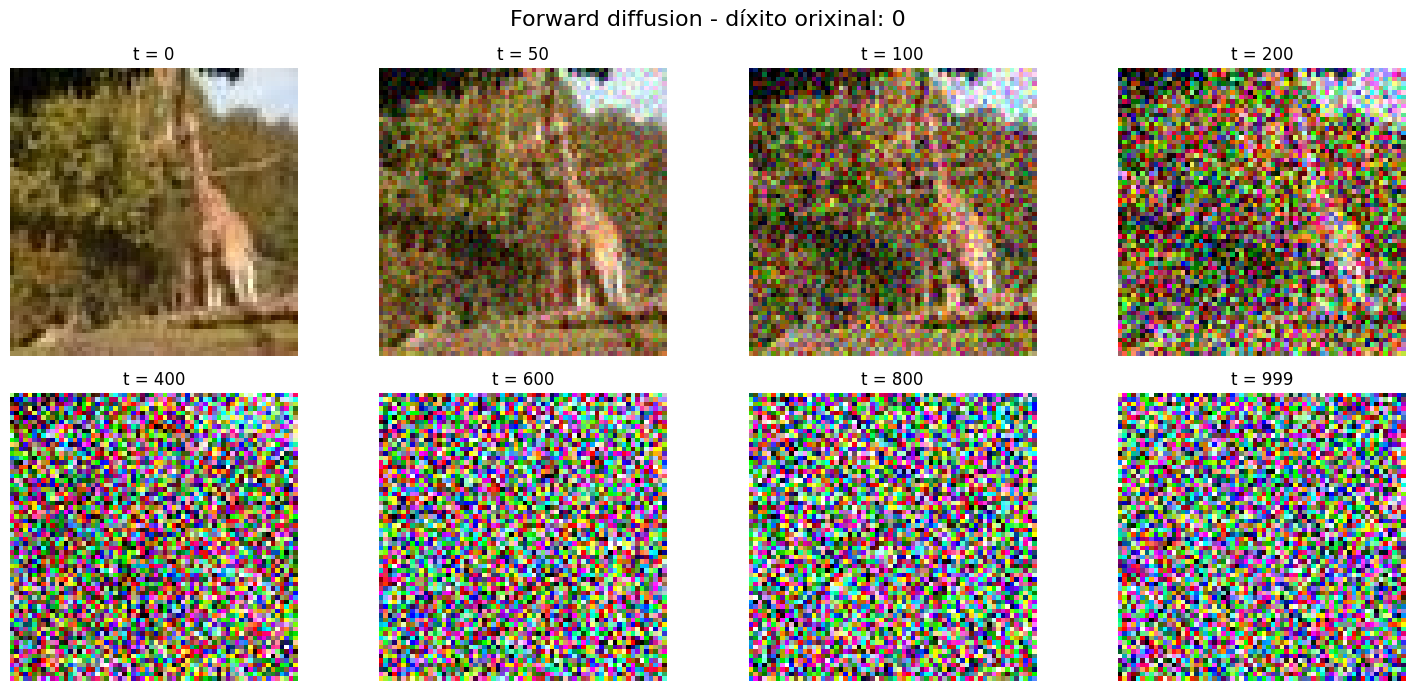

In [22]:
# Seleccionar unha imaxe
img, label = train_dataset[0]
img = img.unsqueeze(0).to(device)

# Visualizar forward diffusion en diferentes pasos
timesteps_to_show = [0, 50, 100, 200, 400, 600, 800, 999]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for idx, t in enumerate(timesteps_to_show):
    ax = axes[idx // 4, idx % 4]

    if t == 0:
        noisy_img = img
    else:
        t_tensor = torch.tensor([t]).to(device)
        noisy_img, _ = forward_diffusion(img, t_tensor, alpha_bar_t)

    # Desnormalizar
    noisy_img = (noisy_img.detach().cpu() * 0.5) + 0.5
    noisy_img = torch.clamp(noisy_img, 0, 1)

    noisy_img = noisy_img.squeeze(0).permute(1, 2, 0)
    ax.imshow(noisy_img)
    ax.set_title(f't = {t}')
    ax.axis('off')

plt.suptitle(f'Forward diffusion - díxito orixinal: {label}', fontsize=16)
plt.tight_layout()
plt.show()

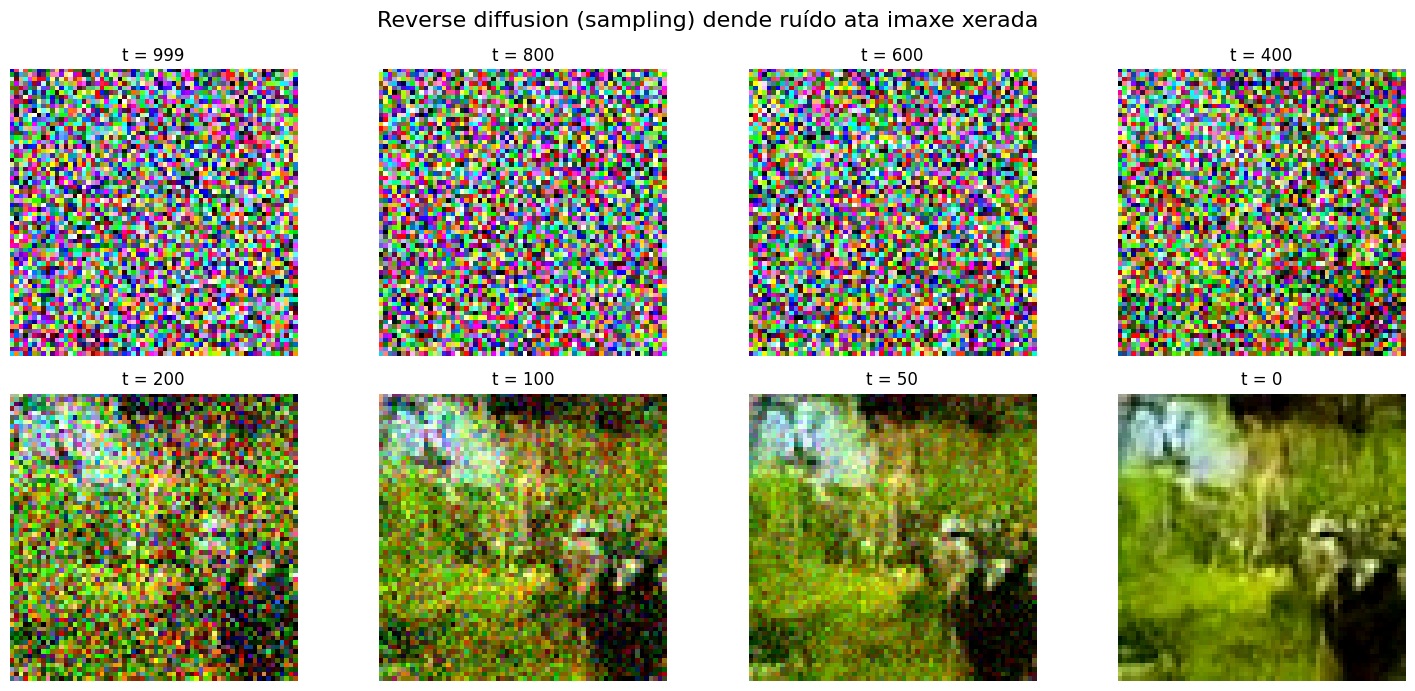

In [23]:
# Visualizar reverse diffusion para unha soa imaxe (comezando dende ruído)
model.eval()
img, label = train_dataset[0]
reverse_timesteps_to_show = [999, 800, 600, 400, 200, 100, 50, 0]
capture_set = set(reverse_timesteps_to_show)
reverse_samples = {}

with torch.no_grad():
    #Cambiamos os canles para RBG e tamaño
    x_t = torch.randn(1, 3, 64, 64).to(device)  # x_T (ruído gaussiano puro, con media=0 e std=1)

    for t_step in reversed(range(T)):  # T-1 -> 0
        # Gardar estado actual x_t nos pasos de interese
        if t_step in capture_set:
            reverse_samples[t_step] = x_t.detach().cpu()

        # Preparar t para o modelo (normalizado)
        t_batch = torch.tensor([t_step], device=device).float() / T
        #t_batch = torch.full((1,), t_step, dtype=torch.long, device=device)
        epsilon_pred = model(x_t, t_batch)

        # Coeficientes (engadimos .view para evitar problemas de broadcasting)
        alpha = alpha_t[t_step].view(-1, 1, 1, 1)
        alpha_bar = alpha_bar_t[t_step].view(-1, 1, 1, 1)
        beta = beta_t[t_step].view(-1, 1, 1, 1)

        if t_step > 0:
            z = torch.normal(mean=torch.zeros_like(x_t), std=torch.ones_like(x_t))
            sigma_t = torch.sqrt(beta)
        else:
            z = torch.zeros_like(x_t)
            sigma_t = torch.tensor(0.0, device=device)

        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * epsilon_pred
        ) + sigma_t * z

# Plot en formato similar ao forward diffusion

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for idx, t_step in enumerate(reverse_timesteps_to_show):

    ax = axes[idx // 4, idx % 4]
    # Recuperar a mostra gardada
    img = reverse_samples[t_step]
    #Desnormalizar e preparar para visualizar (RGB)
    img = (img * 0.5) + 0.5
    img = torch.clamp(img, 0, 1)


    img = img.squeeze(0).permute(1, 2, 0)


    ax.imshow(img)
    ax.set_title(f't = {t_step}')
    ax.axis('off')

plt.suptitle('Reverse diffusion (sampling) dende ruído ata imaxe xerada', fontsize=16)
plt.tight_layout()
plt.show()

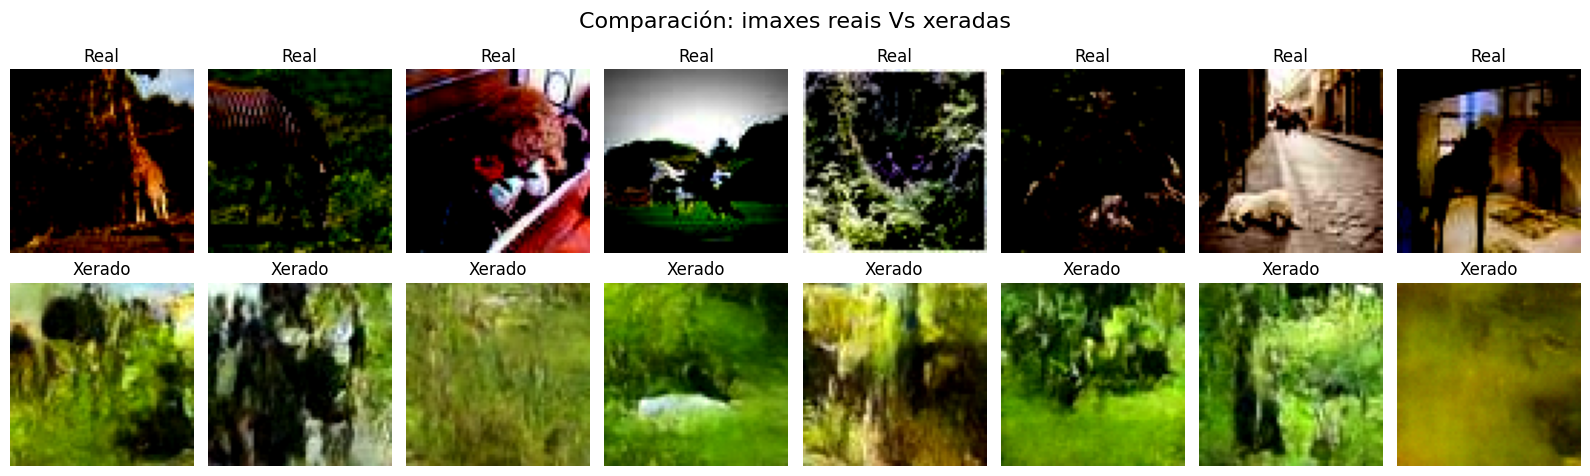

In [24]:
# Mostrar lado a lado imaxes reais e xeradas
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

# Imaxes reais
for i in range(8):
    img, label = train_dataset[i]

    img = img.permute(1, 2, 0)  # CHW → HWC

    axes[0, i].imshow(img)
    axes[0, i].set_title('Real')
    axes[0, i].axis('off')

# Imaxes xeradas
for i in range(8):
    img = generated_images[i].cpu().permute(1, 2, 0)

    axes[1, i].imshow(img)
    axes[1, i].set_title('Xerado')
    axes[1, i].axis('off')

plt.suptitle('Comparación: imaxes reais Vs xeradas', fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights

# A rede InceptionV3 espera imaxes de 3x299x299, así que convertímolas
@torch.no_grad()
def preprocess_for_inception(images):
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    return F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)


@torch.no_grad()
def get_inception_features(images, feature_extractor, batch_size=32):
    features = []

    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i + batch_size].to(device)
        batch = preprocess_for_inception(batch)
        feats = feature_extractor(batch)
        if isinstance(feats, tuple):
            feats = feats[0]
        features.append(feats.cpu())

    return torch.cat(features, dim=0).numpy()


def calculate_fid(real_features, fake_features, eps=1e-6):
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)

    sigma_real = np.cov(real_features, rowvar=False) + eps * np.eye(real_features.shape[1])
    sigma_fake = np.cov(fake_features, rowvar=False) + eps * np.eye(fake_features.shape[1])

    covmean = sqrtm(sigma_real @ sigma_fake)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    diff = mu_real - mu_fake
    return float(diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean))

n_fid = generated_images.shape[0]

real_images = torch.stack([
    torch.clamp((train_dataset[i][0] + 1) / 2, 0, 1)
    for i in range(n_fid)
])

# InceptionV3 para extraer características
inception = inception_v3(weights=Inception_V3_Weights.DEFAULT).to(device)
inception.fc = nn.Identity()
inception.eval()

real_features = get_inception_features(real_images, inception)
fake_features = get_inception_features(generated_images, inception)

fid_score = calculate_fid(real_features, fake_features)

print(f'FID estimado: {fid_score:.2f}')
print(f'Nota: este valor é orientativo, xa que se calcula con poucas ({n_fid}) mostras.')

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 177MB/s]


FID estimado: 293.93
Nota: este valor é orientativo, xa que se calcula con poucas (16) mostras.


In [26]:
n = 10

# Coger varias imágenes reales
imgs = torch.stack([train_dataset[i][0] for i in range(n)])
imgs = imgs.to(device)

# Paso de tiempo (mucho ruido)
t = torch.full((n,), T-1, device=device, dtype=torch.long)

# Asegurar device correcto
alpha_bar_t = alpha_bar_t.to(device)

# Forward diffusion
x_t, _ = forward_diffusion(imgs, t, alpha_bar_t)

In [27]:
@torch.no_grad()
def reconstruct_from_noisy(x_t, model):
    model.eval()

    n = x_t.shape[0]

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device).float() / T  # ✅ FIX

        epsilon_pred = model(x_t, t_batch)

        alpha = alpha_t[t].to(device)
        alpha_bar = alpha_bar_t[t].to(device)
        beta = beta_t[t].to(device)

        if t > 0:
            z = torch.randn_like(x_t)
        else:
            z = torch.zeros_like(x_t)

        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * epsilon_pred
        ) + torch.sqrt(beta) * z

    return x_t

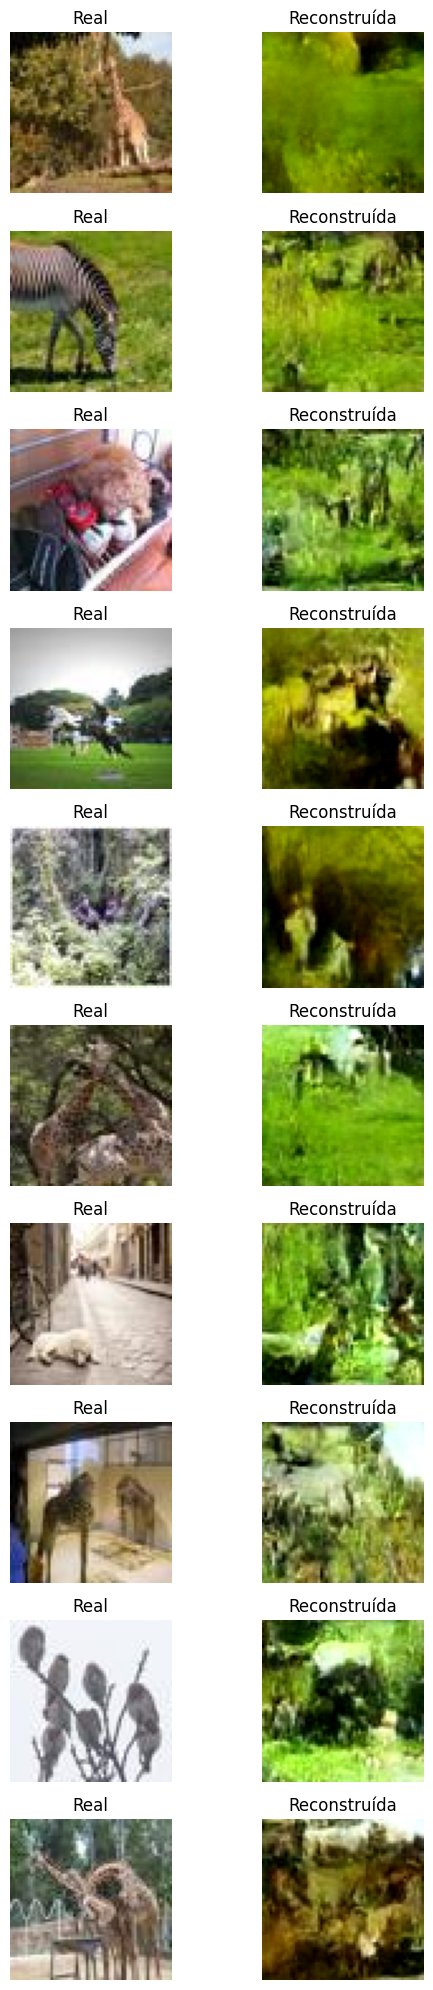

In [28]:
recon = reconstruct_from_noisy(x_t, model)

fig, axes = plt.subplots(n, 2, figsize=(6, 2*n))

for i in range(n):
    # REAL
    img_real = torch.clamp((imgs[i] * 0.5 + 0.5), 0, 1)
    axes[i, 0].imshow(img_real.permute(1,2,0).cpu())
    axes[i, 0].set_title("Real")
    axes[i, 0].axis('off')

    # RECONSTRUIDA
    img_recon = torch.clamp((recon[i] * 0.5 + 0.5), 0, 1)
    axes[i, 1].imshow(img_recon.permute(1,2,0).cpu())
    axes[i, 1].set_title("Reconstruída")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [29]:
# Gardar o modelo adestrado
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'alpha_bar_t': alpha_bar_t,
    'beta_t': beta_t,
    'alpha_t': alpha_t,
    'T': T
}, 'ddpm_coco.pth')

print('Modelo gardado en ddpm_coco.pth')

Modelo gardado en ddpm_coco.pth


#Fase 1

#Para esta fase vamos a definir cuatro funciones que nos faciliten la comparativa de los resultados experimentales que incluyen entrenamiento, visualixacion y métricas

In [30]:
#Entrenamiento
def train_ddpm(model, train_loader, beta_t, alpha_t, alpha_bar_t, T, device, num_epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

    beta_t = beta_t.to(device)
    alpha_t = alpha_t.to(device)
    alpha_bar_t = alpha_bar_t.to(device)

    losses = []

    print(f'Iniciando adestramento por {num_epochs} épocas...\n')

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{num_epochs}')

        for x0, _ in pbar:
            x0 = x0.to(device)
            batch_size = x0.shape[0]

            t = sample_timesteps(batch_size, T).to(device).float() / T
            t_int = (t * (T - 1)).long()

            x_t, epsilon = forward_diffusion(x0, t_int, alpha_bar_t)
            epsilon_pred = model(x_t, t)

            loss = F.mse_loss(epsilon_pred, epsilon)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            losses.append(loss.item())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_loss = epoch_loss / len(train_loader)
        if (epoch + 1) % 10 == 0:

          print(f'Época {(epoch+1)}/{num_epochs} - Perda media: {avg_loss:.4f}')

    print('\nAdestramento completado!')
    return model, losses

In [31]:
#Generación de imágenes
def generate_and_plot(model, device, n_samples=16, image_size=64):
    print('Xerando imaxes novas...')

    generated_images = sample_images(model, n_samples=n_samples, image_size=image_size)

    generated_images = (generated_images * 0.5) + 0.5
    generated_images = torch.clamp(generated_images, 0, 1)

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        img = generated_images[i].cpu().permute(1, 2, 0)
        ax.imshow(img)
        ax.axis('off')

    plt.suptitle('Imaxes xeradas polo DDPM', fontsize=16)
    plt.tight_layout()
    plt.show()

    return generated_images

In [32]:
#Calcular FID
def compute_fid(generated_images, train_dataset, device):
    n_fid = generated_images.shape[0]

    real_images = torch.stack([
        torch.clamp((train_dataset[i][0] + 1) / 2, 0, 1)
        for i in range(n_fid)
    ])

    inception = inception_v3(weights=Inception_V3_Weights.DEFAULT).to(device)
    inception.fc = nn.Identity()
    inception.eval()

    real_features = get_inception_features(real_images, inception)
    fake_features = get_inception_features(generated_images, inception)

    fid_score = calculate_fid(real_features, fake_features)

    print(f'FID estimado: {fid_score:.2f}')
    return fid_score

In [33]:
#Función de evaluación de estrategias
def run_experiment(
    model_class,
    train_loader,
    train_dataset,
    beta_t,
    alpha_t,
    alpha_bar_t,
    T,
    device,
    num_epochs=100,
    experiment_name="exp"
):
    print(f"\n🚀 Ejecutando experimento: {experiment_name}\n")

    # 1. Inicializar modelo
    model = model_class().to(device)

    # 2. Entrenar
    model, losses = train_ddpm(
        model,
        train_loader,
        beta_t,
        alpha_t,
        alpha_bar_t,
        T,
        device,
        num_epochs=num_epochs
    )

    # 3. Generar imágenes
    generated_images = generate_and_plot(model, device)

    # 4. Calcular FID
    fid = compute_fid(generated_images, train_dataset, device)

    print(f"\n✅ Resultado {experiment_name}:")
    print(f"FID: {fid:.2f}")

    return {
        "model": model,
        "losses": losses,
        "fid": fid,
        "images": generated_images
    }

#1. Diferentes estratexias de scheduling (variación do planificador de ruído)

In [34]:
#Modificamos scheduling

def cosine_beta_schedule(timesteps):
    steps = timesteps + 1

    x = torch.linspace(0, timesteps, steps) / timesteps  # ✔️ correcto

    alphas_cumprod = torch.cos((x + 0.008) / 1.008 * torch.pi * 0.5) ** 2  # 🔥 FIX

    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]

    betas = 1.0 - (alphas_cumprod[1:] / alphas_cumprod[:-1])

    beta_t = torch.clip(betas, 1e-4, 0.02)
    alpha_t = 1.0 - beta_t
    alpha_bar_t = torch.cumprod(alpha_t, dim=0)

    return beta_t, alpha_t, alpha_bar_t

# Asigna limite temporal del motor
T = 1000
# Extrae parametros de difusion trigonometrica
beta_t, alpha_t, alpha_bar_t = cosine_beta_schedule(T)




##Entrenamos de nuevo aplicando estrategia scheduling


🚀 Ejecutando experimento: baseline

Iniciando adestramento por 30 épocas...



Época 1/30: 100%|██████████| 174/174 [00:10<00:00, 17.31it/s, loss=0.0392]


Época 1 - Perda media: 0.1925


Época 2/30: 100%|██████████| 174/174 [00:09<00:00, 17.43it/s, loss=0.2104]


Época 2 - Perda media: 0.0907


...

Época 29/30: 100%|██████████| 174/174 [00:09<00:00, 17.41it/s, loss=0.0446]


Época 29 - Perda media: 0.0537


Época 30/30: 100%|██████████| 174/174 [00:10<00:00, 17.34it/s, loss=0.0176]


Época 30 - Perda media: 0.0539

Adestramento completado!
Xerando imaxes novas...


Xerando imaxes: 100%|██████████| 1000/1000 [00:05<00:00, 197.66it/s]


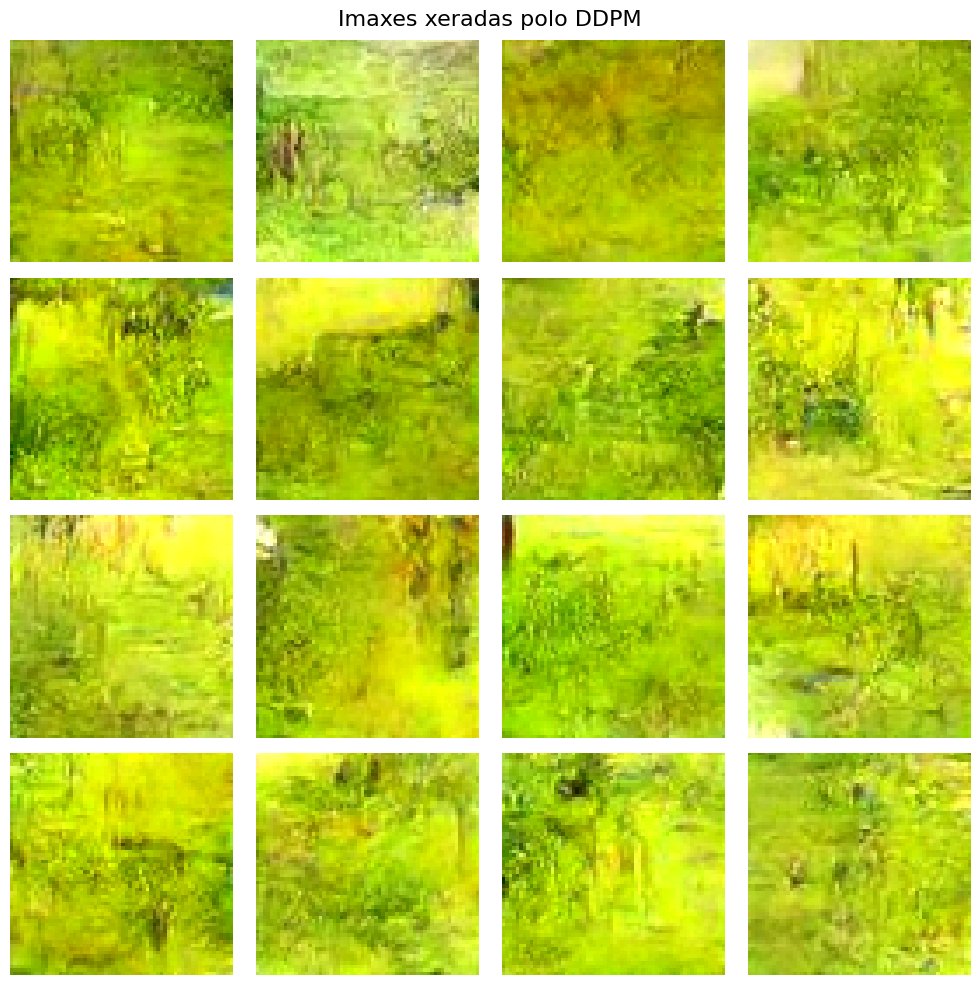

FID estimado: 298.86

✅ Resultado baseline:
FID: 298.86


In [35]:
scheduling =  run_experiment(
    model_class=SimpleUNet,
    train_loader=train_loader,
    train_dataset=train_dataset,
    beta_t=beta_t,
    alpha_t=alpha_t,
    alpha_bar_t=alpha_bar_t,
    T=T,
    device=device,
    num_epochs=n_epocas,
    experiment_name="baseline"
)


In [37]:
#beta_t, alpha_t, alpha_bar_t = linear_beta_schedule(T)

##2. Capas de atención (Self-Attention) na arquitectura da U-Net

In [38]:
class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels

        self.norm = nn.GroupNorm(1, channels)
        self.q = nn.Conv1d(channels, channels, 1)
        self.k = nn.Conv1d(channels, channels, 1)
        self.v = nn.Conv1d(channels, channels, 1)
        self.proj_out = nn.Conv1d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape

        h = self.norm(x)
        h = h.view(B, C, H * W)

        q = self.q(h)
        k = self.k(h)
        v = self.v(h)

        attn = torch.bmm(q.permute(0, 2, 1), k)  # (B, HW, HW)
        attn = attn * (self.channels ** -0.5)
        attn = torch.softmax(attn, dim=-1)

        out = torch.bmm(v, attn.permute(0, 2, 1))
        out = self.proj_out(out)

        out = out.view(B, C, H, W)

        return x + out

In [39]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, time_emb_dim=128, base_channels=128):
        super().__init__()

        # Time embedding
        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        # Encoder
        self.conv_in = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        self.down1 = ResBlock(base_channels, base_channels, time_emb_dim)          # 64x64
        self.down2 = ResBlock(base_channels, base_channels * 2, time_emb_dim)      # 32x32
        self.down3 = ResBlock(base_channels * 2, base_channels * 4, time_emb_dim)  # 16x16

        #  Atención en 16x16
        self.attn1 = SelfAttention(base_channels * 4)

        # Bottleneck
        self.bottleneck = ResBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        #  Atención en bottleneck (8x8)
        self.attn2 = SelfAttention(base_channels * 4)

        # Decoder
        self.up1 = ResBlock(base_channels * 8, base_channels * 2, time_emb_dim)
        self.up2 = ResBlock(base_channels * 4, base_channels, time_emb_dim)
        self.up3 = ResBlock(base_channels * 2, base_channels, time_emb_dim)

        # Output
        self.conv_out = nn.Conv2d(base_channels, out_channels, 1)

        self.pool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Encoder
        x1 = self.conv_in(x)
        x1 = self.down1(x1, t_emb)

        x2 = self.pool(x1)
        x2 = self.down2(x2, t_emb)

        x3 = self.pool(x2)
        x3 = self.down3(x3, t_emb)

        #  Atención en 16x16
        #x3 = self.attn1(x3)
        #x4 = self.attn2(x4)
        x4 = self.pool(x3)

        # Bottleneck
        x4 = self.bottleneck(x4, t_emb)

        #  Atención bottleneck
        x4 = self.attn2(x4)

        # Decoder
        x = self.upsample(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.up1(x, t_emb)

        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, t_emb)

        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up3(x, t_emb)

        return self.conv_out(x)

##Entrenamos de nuevo con capas de atención


🚀 Ejecutando experimento: baseline

Iniciando adestramento por 30 épocas...



Época 1/30: 100%|██████████| 174/174 [00:20<00:00,  8.40it/s, loss=0.0930]


Época 1 - Perda media: 0.1670


Época 2/30: 100%|██████████| 174/174 [00:20<00:00,  8.46it/s, loss=0.0945]


Época 2 - Perda media: 0.0811


...

Época 29/30: 100%|██████████| 174/174 [00:20<00:00,  8.45it/s, loss=0.0588]


Época 29 - Perda media: 0.0510


Época 30/30: 100%|██████████| 174/174 [00:20<00:00,  8.44it/s, loss=0.0538]


Época 30 - Perda media: 0.0516

Adestramento completado!
Xerando imaxes novas...


Xerando imaxes: 100%|██████████| 1000/1000 [00:07<00:00, 142.05it/s]


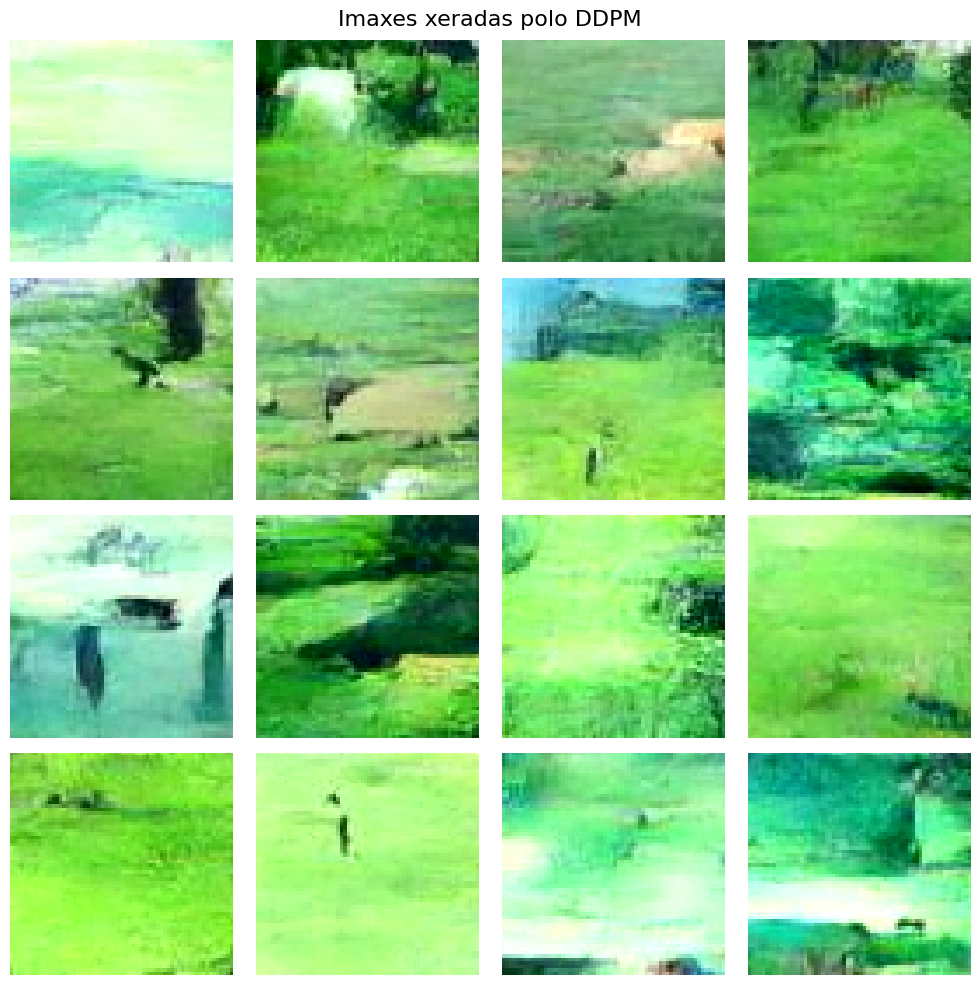

FID estimado: 275.45

✅ Resultado baseline:
FID: 275.45


In [40]:
atencion = run_experiment(
    model_class=SimpleUNet,
    train_loader=train_loader,
    train_dataset=train_dataset,
    beta_t=beta_t,
    alpha_t=alpha_t,
    alpha_bar_t=alpha_bar_t,
    T=T,
    device=device,
    num_epochs=n_epocas,
    experiment_name="baseline"
)

##Data Augmentation sobre as imaxes de adestramento


In [41]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),

    #  DATA AUGMENTATION
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),  # leve
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # Opcional pero útil
    transforms.RandomResizedCrop(64, scale=(0.9, 1.0)),

    # Normalización final
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

##Entrenamos de nuevo con Aumentation


🚀 Ejecutando experimento: baseline

Iniciando adestramento por 30 épocas...



Época 1/30: 100%|██████████| 174/174 [00:20<00:00,  8.44it/s, loss=0.0461]


Época 1 - Perda media: 0.1627


Época 2/30: 100%|██████████| 174/174 [00:20<00:00,  8.46it/s, loss=0.0321]


Época 2 - Perda media: 0.0824


...

Época 29/30: 100%|██████████| 174/174 [00:20<00:00,  8.44it/s, loss=0.0069]


Época 29 - Perda media: 0.0507


Época 30/30: 100%|██████████| 174/174 [00:20<00:00,  8.42it/s, loss=0.0389]


Época 30 - Perda media: 0.0506

Adestramento completado!
Xerando imaxes novas...


Xerando imaxes: 100%|██████████| 1000/1000 [00:07<00:00, 142.35it/s]


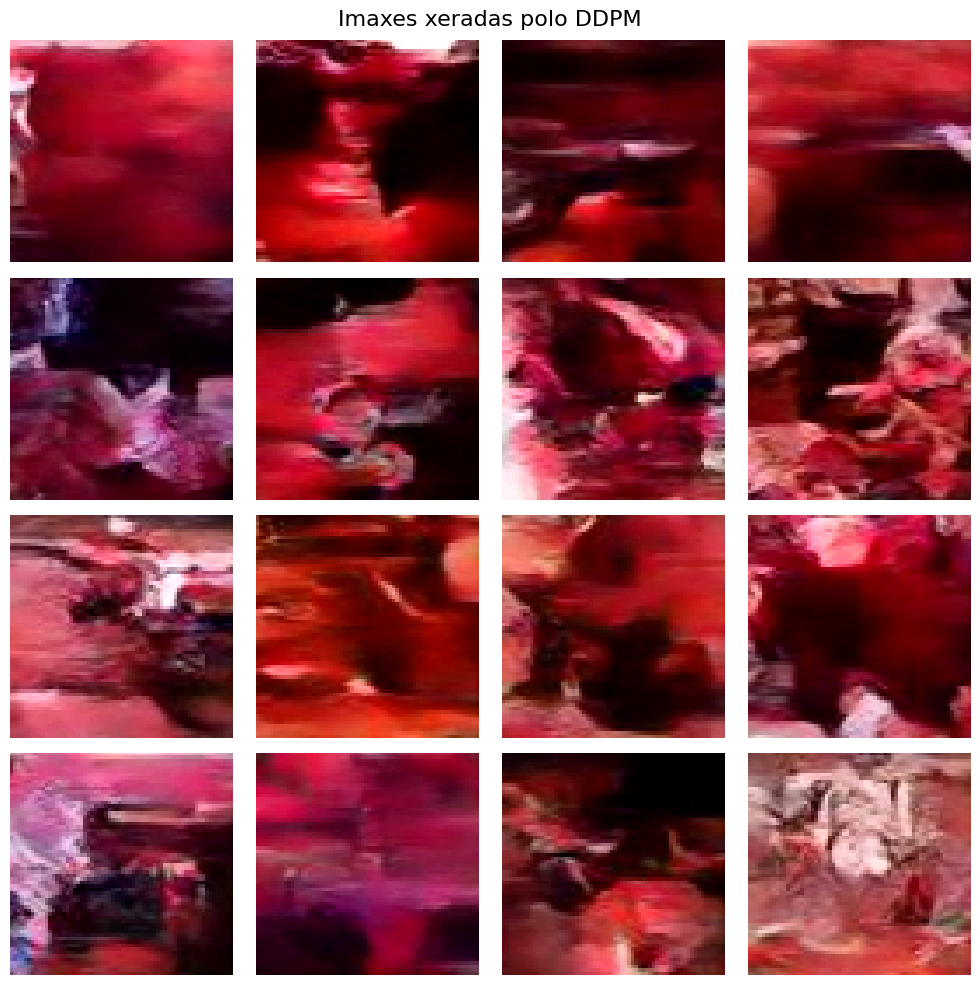

FID estimado: 291.22

✅ Resultado baseline:
FID: 291.22


In [42]:
Augmentation = run_experiment(
    model_class=SimpleUNet,
    train_loader=train_loader,
    train_dataset=train_dataset,
    beta_t=beta_t,
    alpha_t=alpha_t,
    alpha_bar_t=alpha_bar_t,
    T=T,
    device=device,
    num_epochs=n_epocas,
    experiment_name="baseline"
)

In [ ]:
n = 10

# Coger varias imágenes reales
imgs = torch.stack([train_dataset[i][0] for i in range(n)])
imgs = imgs.to(device)

# Paso de tiempo (mucho ruido)
t = torch.full((n,), T-1, device=device, dtype=torch.long)

# Asegurar device correcto
alpha_bar_t = alpha_bar_t.to(device)

# Forward diffusion
x_t, _ = forward_diffusion(imgs, t, alpha_bar_t)

In [ ]:
@torch.no_grad()
def reconstruct_from_noisy(x_t, model):
    model.eval()

    n = x_t.shape[0]

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device).float() / T  # ✅ FIX

        epsilon_pred = model(x_t, t_batch)

        alpha = alpha_t[t].to(device)
        alpha_bar = alpha_bar_t[t].to(device)
        beta = beta_t[t].to(device)

        if t > 0:
            z = torch.randn_like(x_t)
        else:
            z = torch.zeros_like(x_t)

        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * epsilon_pred
        ) + torch.sqrt(beta) * z

    return x_t

In [ ]:
recon = reconstruct_from_noisy(x_t, model)

fig, axes = plt.subplots(n, 2, figsize=(6, 2*n))

for i in range(n):
    # REAL
    img_real = torch.clamp((imgs[i] * 0.5 + 0.5), 0, 1)
    axes[i, 0].imshow(img_real.permute(1,2,0).cpu())
    axes[i, 0].set_title("Real")
    axes[i, 0].axis('off')

    # RECONSTRUIDA
    img_recon = torch.clamp((recon[i] * 0.5 + 0.5), 0, 1)
    axes[i, 1].imshow(img_recon.permute(1,2,0).cpu())
    axes[i, 1].set_title("Reconstruída")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Gardar o modelo adestrado
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'alpha_bar_t': alpha_bar_t,
    'beta_t': beta_t,
    'alpha_t': alpha_t,
    'T': T
}, 'ddpm_coco_opt.pth')

print('Modelo gardado en ddpm_coco_opt.pth')

##Fase II

#Extracción de prompts: Recuperar os captions (descricións textuais) asociados ás imaxes do voso dominio dende as anotacóons de COCO

In [ ]:
import shutil
#Copiar captions
shutil.copy(
    "/root/fiftyone/coco-2017/raw/captions_train2017.json",
    "/content/captions_train2017.json"
)

In [ ]:
#Copiar instances
shutil.copy(
    "/root/fiftyone/coco-2017/raw/instances_train2017.json",
    "/content/instances_train2017.json"
)

In [ ]:
from pycocotools.coco import COCO

coco_det = COCO("/content/coco_train/labels.json")
coco_caps = COCO("/content/captions_train2017.json")

In [ ]:
images_dir = "/content/coco_train/data"

In [ ]:
#Unir todo
import os
import random

final_data = []

img_ids = coco_det.getImgIds()

for img_id in img_ids:
    img = coco_det.loadImgs(img_id)[0]

    img_path = os.path.join(images_dir, img["file_name"])

    # captions
    cap_ids = coco_caps.getAnnIds(imgIds=img_id)
    cap_anns = coco_caps.loadAnns(cap_ids)

    if len(cap_anns) == 0:
        continue

    caption = random.choice(cap_anns)["caption"]

    final_data.append({
        "image": img_path,
        "caption": caption
    })

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

item = final_data[0]

img = Image.open(item["image"])
caption = item["caption"]

plt.imshow(img)
plt.title(caption)
plt.axis("off")
plt.show()

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class ImageTextDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        image = Image.open(item["image"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, item["caption"]
        #return image, 0

In [ ]:
!zip -r coco_2000_200.zip /content/coco_train /content/captions_train2017.json /content/ddpm_coco.pth /content/instances_train2017.json

#Xeración Latente: Utilizar un modelo preadestrado (Stable Diffusion) para xerar imaxes de alta resolución baseadas neses textos, actuando como o módulo de “creación dirixida” do editor.
